### Colab setup

Run the cell below first. It installs the packages Colab does not ship with
(`numpy`, `scipy`, `sympy` and `matplotlib` are already there). Figures are
loaded from the course site, so this notebook needs a network connection --
the copy in the repo is the one to use offline.


In [ ]:
%pip install -q control


# PSE-823: Advanced Process Dynamics and Control
## Python Primer -- The Libraries We Will Use
### Warm-up before Lecture 3

Date: __________

## How to use this notebook

- Every code cell is **live**: select it, press `Shift+Enter`
- Cells share memory, so run them **top to bottom**
- Change a number, re-run, watch what moves
- One running example the whole way through:

  a first-order process, $\tau \dfrac{dy}{dt} + y = K\,x$

## Agenda

1. **Python basics** -- variables, lists, loops, functions
2. **NumPy** -- arrays of numbers
3. **Matplotlib** -- plotting
4. **SymPy** -- symbolic algebra and Laplace transforms
5. **SciPy** -- numerical ODEs and curve fitting
6. **python-control** -- transfer functions and responses
7. **Putting it together** -- one problem, three ways

## Our running example

Lecture 2's mixing tank:

$$5\,\frac{dC_A}{dt} + C_A = 2, \qquad C_A(0) = 3$$

- Time constant $\tau = 5$ min
- Final value $C_A(\infty) = 2$ g/L
- Exact answer: $C_A(t) = 2 + e^{-t/5}$

Each library will get us to this same curve in its own way.

# Part 1
## Python basics
### Just enough to read the rest of the course

### Variables and comments

- `name = value` stores a value under a name
- `#` starts a comment -- Python ignores the rest of the line
- `print(...)` shows values

In [ ]:
# time constant and gain of a first-order process
tau = 5.0        # time constant, min
K = 1.0          # steady-state gain
print(tau, K)    # print shows the values

### Arithmetic and formatted output

- `+ - * /` as usual, `**` for powers
- An **f-string** drops values into text: `f"... {x} ..."`
- `:.2f` inside the braces means two decimals

In [ ]:
t = 10.0                         # min
ratio = t / tau                  # how many time constants?
print(f"t/tau = {ratio}")
print(f"t/tau = {ratio:.2f}")    # two decimal places
print(f"tau squared = {tau**2}") # ** is a power

### Lists and loops

- A list holds several values: `[a, b, c]`
- `for` repeats the **indented** lines once per item

In [ ]:
times = [0, 5, 10, 15]           # a list of times, min
for x in times:                  # x takes each value in turn
    print(x, x / tau)            # indented = inside the loop
# times / tau   # <- uncomment: TypeError. Lists can't do math.

### Functions

- `def name(inputs):` packages a calculation for reuse
- `return` sends the answer back
- `K=1.0` gives an input a **default** value

In [ ]:
import math                          # standard-library math

def step_resp(t, tau, K=1.0):
    # unit-step response of a first-order system
    return K * (1 - math.exp(-t / tau))

print(step_resp(5.0, tau=5.0))       # t = tau  ->  63.2 %

### Where plain Python runs out

- `math.exp` handles **one** number at a time
- We want a whole curve: hundreds of times at once
- Answer: **NumPy** arrays

In [ ]:
# step_resp([0, 5, 10], tau=5.0)   # <- uncomment: TypeError
for x in [0, 5, 10]:               # workable, but clumsy
    print(x, round(step_resp(x, 5.0), 3))

Part 1 talking points: keep this under ten minutes. The goal is only that students can read a script:
assignment, comment, f-string, loop, function. The failing lines are commented out on purpose;
uncomment one live if the class is curious what the error message looks like.

# Part 2
## NumPy
### Arrays: whole curves in one line

### Import and the first array

- `import numpy as np` -- everyone abbreviates it `np`
- An **array** is a list that can do math

In [ ]:
import numpy as np

t = np.array([0, 5, 10, 15])   # array of times, min
print(t / 5)                   # math applies to every element
print(t.shape)                 # (4,) -> four numbers

### Making time grids

- `np.linspace(start, stop, n)` -- `n` evenly spaced points, **including** the end
- `np.arange(start, stop, step)` -- fixed step, **excluding** the end

In [ ]:
print(np.linspace(0, 25, 6))    # 6 points from 0 to 25
print(np.arange(0, 25, 5))      # step 5, stops before 25
t = np.linspace(0, 25, 251)     # fine grid: dt = 0.1 min
print(len(t), t[:3])            # count, first three values

### Vectorized math

- `np.exp`, `np.sin`, `np.sqrt`, ... work on **whole arrays**
- No loop needed: the function of every element at once

In [ ]:
tau = 5.0
y = 1 - np.exp(-t / tau)           # step response, all 251 points
print(np.round(y[:5], 4))          # peek at the first five
print(f"y at t = 25: {y[-1]:.4f}") # index -1 is the last element

### Indexing and slicing

- Counting starts at **0**: `y[0]` is the first element
- `y[a:b]` -- elements `a` up to (not including) `b`
- `y[-1]` -- the last element

In [ ]:
t5 = np.linspace(0, 25, 6)         # 0, 5, 10, ...
y5 = 1 - np.exp(-t5 / 5)
print(y5[1])                       # t = 5 = tau: 63.2 %
print(y5[1:4])                     # elements 1, 2, 3
print(y5[::2])                     # every second element

### Asking questions of an array

- `y >= 0.98` gives an array of True/False
- `np.argmax(mask)` -- index of the **first** True
- Result: how long until 98 % complete?

In [ ]:
mask = y >= 0.98                   # True once we are within 2 %
i = np.argmax(mask)                # first index where True
print(f"98% at t = {t[i]:.1f} min  (4 tau = {4*tau} min)")

### Matrices

- A list of lists becomes a 2-D array
- `@` is matrix multiplication
- `np.linalg.eigvals` -- eigenvalues, i.e. the **poles** of $\dot{x} = Ax$

In [ ]:
A = np.array([[0, 1],
              [-2, -3]])           # 2 x 2 matrix
x = np.array([1, 0])
print(A @ x)                       # matrix-vector product
print(np.linalg.eigvals(A))        # poles at -1 and -2

Part 2: emphasize "no loops". The 98 % question is the same reading we will do off plots in Lecture 3.
The matrix slide is only a preview for the state-space section later in the course.

# Part 3
## Matplotlib
### Turning arrays into figures

### The one-line plot

- `plt.plot(x, y)` draws, `plt.show()` displays
- Fine for a quick look, not for a report

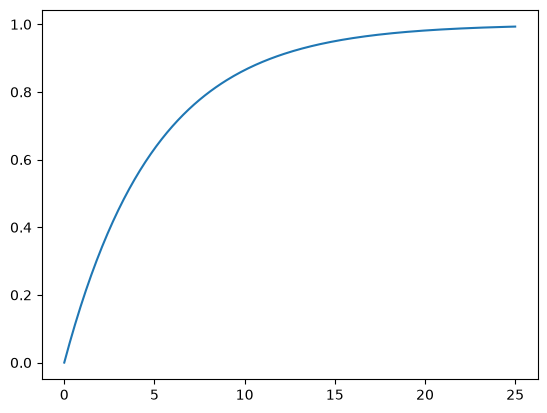

In [ ]:
import matplotlib.pyplot as plt

plt.plot(t, y)               # y = 1 - exp(-t/5) from before
plt.show()                   # display the figure

### Labels make it a figure

- Always: axis labels **with units**, and a grid
- Fonts are small by default; raise them for the classroom

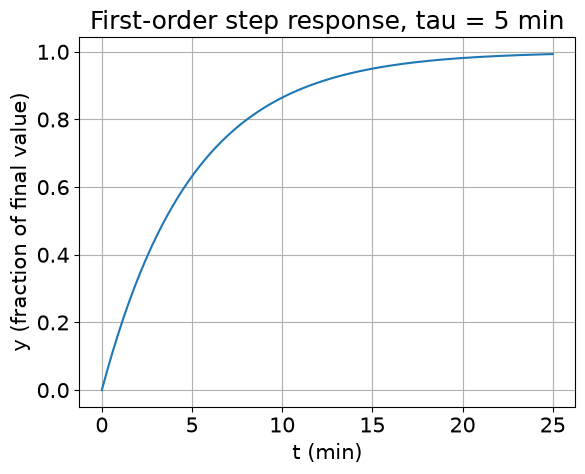

In [ ]:
plt.rcParams.update({"font.size": 15})   # bigger text everywhere

plt.plot(t, y)
plt.xlabel("t (min)")
plt.ylabel("y (fraction of final value)")
plt.title("First-order step response, tau = 5 min")
plt.grid(True)
plt.show()

### Figure and axes objects

- `fig, ax = plt.subplots()` gives you handles to control
- Several curves: call `ax.plot` repeatedly, add `label=`
- `ax.legend()` draws the key

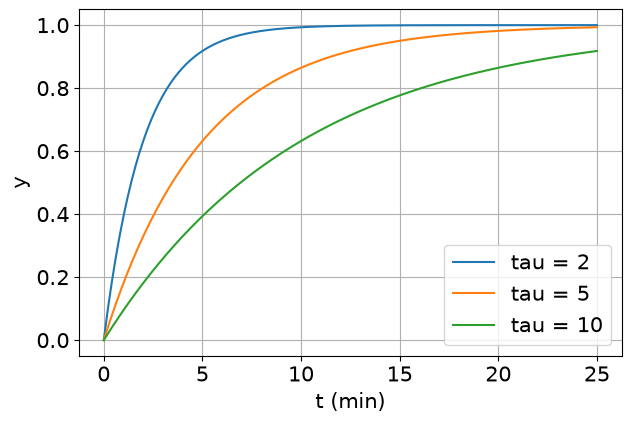

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for tau_i in [2, 5, 10]:                    # three time constants
    ax.plot(t, 1 - np.exp(-t / tau_i), label=f"tau = {tau_i}")
ax.set_xlabel("t (min)"); ax.set_ylabel("y")
ax.grid(True); ax.legend()
plt.show()

### Reference lines and annotations

- `ax.axhline` / `ax.axvline` -- horizontal / vertical guides
- `ls="--"` dashed, `color="k"` black
- Mark the 63.2 % point at $t = \tau$

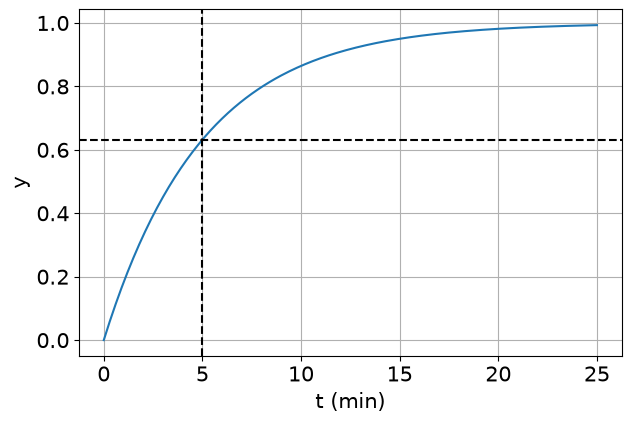

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(t, 1 - np.exp(-t / 5))
ax.axhline(0.632, ls="--", color="k")      # 63.2 % level
ax.axvline(5, ls="--", color="k")          # t = tau
ax.set_xlabel("t (min)"); ax.set_ylabel("y")
ax.grid(True)
plt.show()

### Two panels: input and output

- `plt.subplots(2, 1, sharex=True)` stacks two plots on one time axis
- `ax.step` draws a piecewise-constant signal

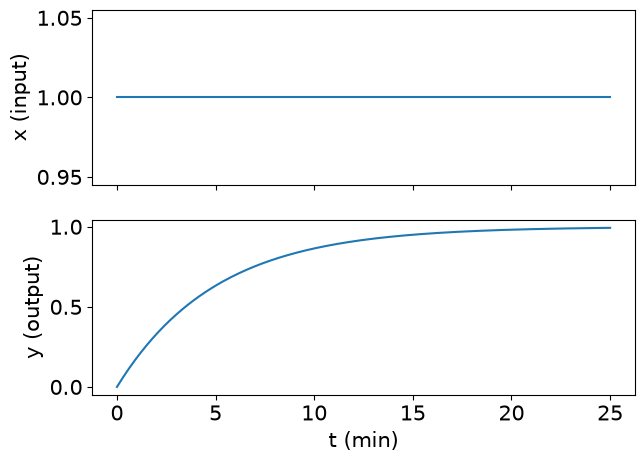

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(7, 5))
ax1.step(t, np.ones_like(t), where="post")     # unit step input
ax1.set_ylabel("x (input)")
ax2.plot(t, 1 - np.exp(-t / 5))                # response
ax2.set_ylabel("y (output)"); ax2.set_xlabel("t (min)")
plt.show()

Part 3: stress "labels with units, always". Students lose marks on unlabeled axes.
Change tau in the three-curve cell live to show how the shape depends on it.

# Part 4
## SymPy
### Algebra, calculus and Laplace transforms by computer

### Symbols and expressions

- `sp.symbols("s t")` creates unknowns, not numbers
- The **last line** of a cell is displayed, typeset

In [ ]:
import sympy as sp

s, t = sp.symbols("s t")        # symbols, not numbers
G = 1 / (5*s + 1)               # a transfer function
G                               # last line is displayed

### Algebra

- `sp.factor` -- factor a polynomial (find the poles)
- `sp.expand` -- multiply out
- `sp.simplify` -- tidy an expression

In [ ]:
den = s**2 + 3*s + 2
print(sp.factor(den))                       # (s + 1)(s + 2)
print(sp.expand((s + 1) * (s + 2)))         # back again
print(sp.solve(den, s))                     # roots: the poles

### Calculus

- `sp.diff(f, x)` -- derivative
- `sp.integrate(f, x)` -- integral

In [ ]:
y_t = 1 - sp.exp(-t / 5)                    # step response
print(sp.diff(y_t, t))                      # slope of the curve
print(sp.diff(y_t, t).subs(t, 0))           # initial slope = 1/tau
print(sp.integrate(y_t, (t, 0, 5)))         # area from 0 to 5

### Laplace transforms

- `sp.laplace_transform(f, t, s)` -- time domain to $s$
- `noconds=True` hides convergence conditions

In [ ]:
f = sp.exp(-t / 5)
F = sp.laplace_transform(f, t, s, noconds=True)
F                                           # 1 / (s + 1/5)

### Partial fractions and the inverse

- `sp.apart` -- partial fractions, by hand no more
- `sp.inverse_laplace_transform` -- back to time
- `Heaviside(t)` is just the unit step: read it as 1 for $t > 0$

In [ ]:
Y = 1 / (s * (5*s + 1))            # unit step through 1/(5s+1)
print(sp.apart(Y, s))              # partial fractions
sp.inverse_laplace_transform(Y, s, t)

### Solving an ODE symbolically

- Declare an unknown **function**: `sp.Function("y")`
- `sp.dsolve(ode, y(t), ics={...})` with the initial condition
- Our mixing tank: $5\dot{C} + C = 2$, $C(0) = 3$

In [ ]:
C = sp.Function("C")
ode = sp.Eq(5 * C(t).diff(t) + C(t), 2)
sol = sp.dsolve(ode, C(t), ics={C(0): 3})
sol                                # C(t) = 2 + exp(-t/5)

### Bridge to NumPy: lambdify

- A symbolic answer is not plottable yet
- `sp.lambdify` turns it into a fast NumPy function

In [ ]:
C_exact = sp.lambdify(t, sol.rhs, "numpy")   # symbolic -> function
tt = np.array([0, 5, 10, 25])
print(C_exact(tt))                           # 3.0, 2.37, 2.14, 2.007

Part 4: SymPy replaces the partial-fraction algebra from Lecture 2, it does not replace understanding it.
Do the partial fractions by hand first, then let apart() confirm.
lambdify is the bridge that lets an exact symbolic result be compared against a numerical one later.

# Part 5
## SciPy
### Numerical ODEs and fitting data

### Integrating an ODE numerically

- Write the ODE as $\dot{y} = f(t, y)$ in a Python function
- `solve_ivp(f, [t0, tf], [y0])` steps it forward
- Our tank: $\dot{C} = (2 - C)/5$

In [ ]:
from scipy.integrate import solve_ivp

def mixing(t, C):                      # C is a list of states
    return [(2 - C[0]) / 5]            # dC/dt

tt = np.linspace(0, 25, 251)
sol_n = solve_ivp(mixing, [0, 25], [3.0], t_eval=tt)
print(sol_n.y[0][:3])                  # first three values

### Check against the exact answer

- `sol_n.t` times, `sol_n.y[0]` first state
- Numerical and exact should agree to within tolerance

In [ ]:
C_num = sol_n.y[0]
C_ex = 2 + np.exp(-tt / 5)             # from SymPy earlier
err = np.abs(C_num - C_ex).max()
print(f"max |numerical - exact| = {err:.1e} g/L")

### Plot: numerical vs exact

- Dots are the solver, line is the formula
- On top of each other: the solver is doing its job

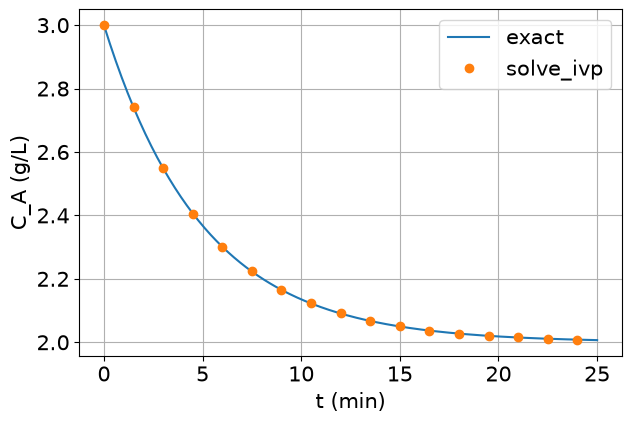

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(tt, C_ex, label="exact")
ax.plot(tt[::15], C_num[::15], "o", label="solve_ivp")
ax.set_xlabel("t (min)"); ax.set_ylabel("C_A (g/L)")
ax.grid(True); ax.legend()
plt.show()

### Passing parameters

- Extra values go in `args=(...)` after $t$ and the states
- One function then serves any $\tau$, $K$ and input

In [ ]:
def first_order(t, y, tau, K, x):
    return [(K * x - y[0]) / tau]      # tau y' + y = K x

r = solve_ivp(first_order, [0, 25], [0.0], t_eval=tt,
              args=(5.0, 2.0, 1.0))    # tau=5, K=2, step of 1
print(f"final value: {r.y[0][-1]:.3f}  (K*x = 2, after 5 tau)")

### Fitting a model to data

- `curve_fit(model, x, y, p0=guess)` finds the best parameters
- Real plant data are noisy; here we fake some
- Recover $K$ and $\tau$ from the noisy step test

In [ ]:
from scipy.optimize import curve_fit

rng = np.random.default_rng(0)               # repeatable noise
y_meas = 2*(1 - np.exp(-tt/5)) + rng.normal(0, 0.05, tt.size)

def model(t, K, tau):
    return K * (1 - np.exp(-t / tau))

(K_fit, tau_fit), _ = curve_fit(model, tt, y_meas, p0=[1, 1])
print(f"K = {K_fit:.2f} (true 2),  tau = {tau_fit:.2f} (true 5)")

### Plot: data and fitted model

- Dots: the noisy "measurements"
- Line: the fitted first-order model

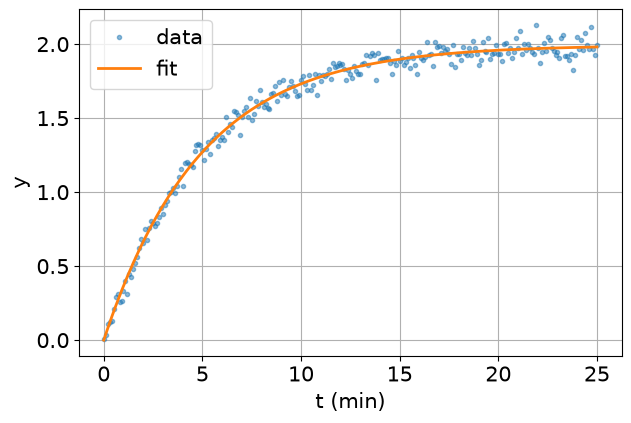

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(tt, y_meas, ".", alpha=0.5, label="data")
ax.plot(tt, model(tt, K_fit, tau_fit), lw=2, label="fit")
ax.set_xlabel("t (min)"); ax.set_ylabel("y")
ax.grid(True); ax.legend()
plt.show()

Part 5: solve_ivp is the tool for anything nonlinear later in the course (phase plane, reactors).
curve_fit is the same step-test identification idea used for tuning and process identification.

# Part 6
## python-control
### Transfer functions, poles and responses

### A transfer function object

- `ct.tf(num, den)` -- coefficient lists, **highest power first**
- $G(s) = \dfrac{1}{5s + 1}$ is `tf([1], [5, 1])`

In [ ]:
# pip install control   (Colab only)
import control as ct

G = ct.tf([1], [5, 1])       # G(s) = 1 / (5 s + 1)
print(G)

### Poles, zeros, gain

- Poles: where the denominator is zero
- Steady-state gain: $G(0)$
- Time constant: $\tau = -1/\text{pole}$

In [ ]:
print("poles:", ct.poles(G))          # -0.2  ->  tau = 5
print("zeros:", ct.zeros(G))          # none
print("gain :", ct.dcgain(G))         # G(0) = 1

### Step response

- `ct.step_response(G, t)` returns an object
- `.time` and `.outputs` hold the numbers
- Compare with $1 - e^{-t/5}$

In [ ]:
t = np.linspace(0, 25, 251)
resp = ct.step_response(G, t)
print(resp.outputs[:3])                       # first three values
print(np.abs(resp.outputs - (1 - np.exp(-t/5))).max())

### Plot: step response

- Same curve as the NumPy formula, no algebra needed
- Works for any transfer function

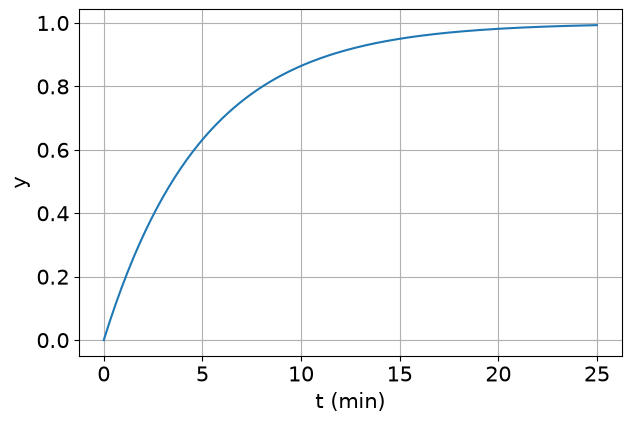

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(resp.time, resp.outputs)
ax.set_xlabel("t (min)"); ax.set_ylabel("y")
ax.grid(True)
plt.show()

### Combining blocks

- `G1 * G2` -- blocks in **series** (multiply)
- Two tanks in series: a second-order system
- Poles are the roots of the combined denominator

In [ ]:
G1 = ct.tf([1], [2, 1])         # tank 1, tau = 2
G2 = ct.tf([1], [3, 1])         # tank 2, tau = 3
G12 = G1 * G2                   # series connection
print(G12)
print("poles:", ct.poles(G12))  # -0.5 and -0.33

### Second-order behavior

- $G(s) = \dfrac{1}{\tau^2 s^2 + 2\zeta\tau s + 1}$
- Damping ratio $\zeta$ sets the shape
- Underdamped $\zeta < 1$, critical $\zeta = 1$, overdamped $\zeta > 1$

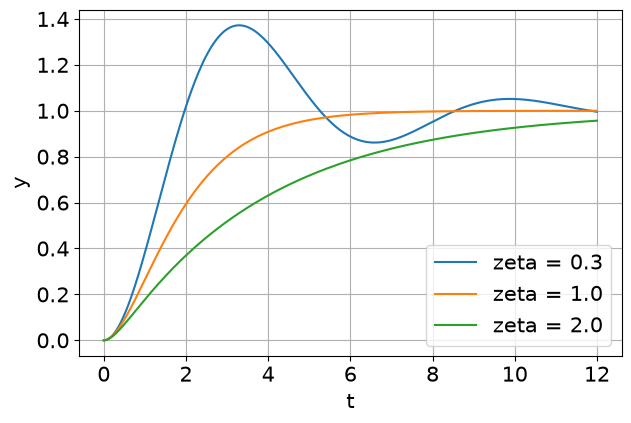

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for zeta in [0.3, 1.0, 2.0]:
    G2nd = ct.tf([1], [1, 2*zeta, 1])            # tau = 1
    r = ct.step_response(G2nd, np.linspace(0, 12, 400))
    ax.plot(r.time, r.outputs, label=f"zeta = {zeta}")
ax.set_xlabel("t"); ax.set_ylabel("y"); ax.grid(True); ax.legend()
plt.show()

### Any input signal

- `ct.forced_response(G, t, u)` -- response to an input array $u(t)$
- Try a sine wave: the output is a **lagged, smaller** sine

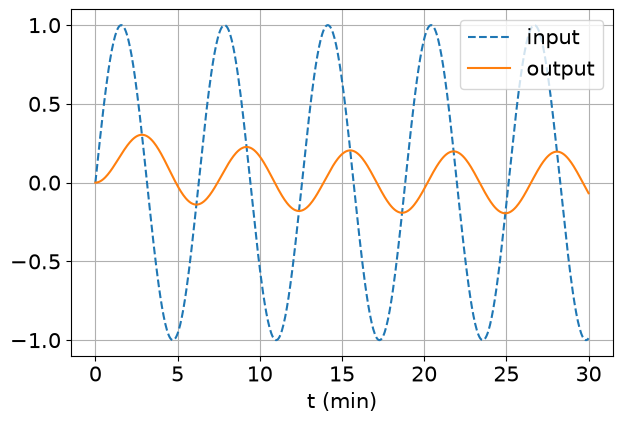

In [ ]:
t = np.linspace(0, 30, 601)
u = np.sin(1.0 * t)                          # input, 1 rad/min
out = ct.forced_response(G, t, u)            # G = 1/(5s+1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(t, u, "--", label="input")
ax.plot(t, out.outputs, label="output")
ax.set_xlabel("t (min)"); ax.grid(True); ax.legend()
plt.show()

Part 6: python-control is the workhorse from Lecture 3 onward. Point out that the series product is the same
block-diagram algebra done on paper. The forced_response slide previews frequency response
(amplitude ratio and phase lag) that we meet later.

# Part 7
## Putting it together
### One problem, three routes to the same curve

### The same answer three ways

- Formula (NumPy), ODE solver (SciPy), transfer function (python-control)
- If all three agree, we can trust each one

In [ ]:
tau, K = 5.0, 2.0
t = np.linspace(0, 25, 251)

exact = K * (1 - np.exp(-t / tau))
ode = solve_ivp(lambda t, y: [(K - y[0]) / tau],
                [0, 25], [0.0], t_eval=t).y[0]
tf_out = ct.step_response(ct.tf([K], [tau, 1]), t).outputs

# largest differences: small numbers mean the routes agree
print(np.abs(exact - ode).max(), np.abs(exact - tf_out).max())

### Cheat sheet

| Library | Job in this course | Calls to remember |
|---|---|---|
| NumPy | arrays, time grids | `np.linspace`, `np.exp`, `np.argmax` |
| Matplotlib | figures | `plt.subplots`, `ax.plot`, `ax.legend` |
| SymPy | algebra, Laplace | `sp.apart`, `sp.dsolve`, `sp.laplace_transform` |
| SciPy | ODEs, fitting | `solve_ivp`, `curve_fit` |
| python-control | transfer functions | `ct.tf`, `ct.step_response`, `ct.poles` |

### Common stumbles

- `NameError`: you skipped a cell. Run from the top, or **Kernel > Restart & Run All**
- `IndentationError`: lines inside a loop or function must be indented equally
- Unbalanced brackets: count `(` against `)`
- Coefficient order in `ct.tf` is highest power **first**
- Read the **last line** of an error message first

### Coming later in the course

- **GEKKO** -- optimization and Model Predictive Control (not needed today)
- `ct.bode_plot`, `ct.margin` -- frequency response and stability
- `ct.ss` -- state-space models, using the matrix tools from Part 2

## Wrap-up

- Six tools: **Python**, **NumPy**, **Matplotlib**, **SymPy**, **SciPy**, **python-control**
- Every lecture from now on runs on these
- Change a number and re-run: that is how you learn them

**Next: Lecture 3 -- first-order systems, by simulation**